## **ArXiv Dataset's NLP Project : Text Classification For Topic Modelling**

#### Machine learning Supervised Learning models used **SVM, KNN,Random Forest Classifier** .
#### Unsupervised technique **LDA - LatentDirichletAllocation.** 

- **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import re
import os
import string
import kagglehub
import json

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import pyLDAvis
import pyLDAvis.lda_model
import scipy.sparse as sp
from collections import Counter
from wordcloud import WordCloud,STOPWORDS
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer


import warnings
warnings.filterwarnings('ignore')

import joblib

- **Dataset Loading**

In [3]:
path = kagglehub.dataset_download("Cornell-University/arxiv")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\pc\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\304


- **Inspecting Data**

As the full dataset contains more than millions of papers ,it is parsed into a subset of 18000 papers.

In [4]:
# Parsing broad main categories from the arXiv dataset 
print("- Parsing broad main categories from the arXiv dataset: ")
from collections import defaultdict
json_file_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
TARGET_PER_CLASS = 2000
parsed_papers = []
class_counts = defaultdict(int)

with open(json_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        paper = json.loads(line)
        primary_tag = paper['categories'].split(' ')[0]

        if primary_tag.startswith('cs.'): group = 'computer-science'
        elif primary_tag.startswith('math.'): group = 'mathematics'
        elif primary_tag.startswith('stat.'): group = 'statistics'
        elif primary_tag.startswith('econ.'): group = 'economics'
        elif primary_tag.startswith('q-fin.'): group = 'quantitative-finance'
        elif primary_tag.startswith('astro-ph'): group = 'astrophysics'
        elif primary_tag.startswith('quant-ph'): group = 'quantum-physics'
        elif primary_tag.startswith('hep-'): group = 'high-energy-physics'
        elif primary_tag.startswith('gr-qc'): group = 'general-relativity'
        else: continue

        if class_counts[group] < TARGET_PER_CLASS:
            raw_full_text = f"{paper['title']}. {paper['abstract']}".replace('\n', ' ').strip()
            parsed_papers.append({'text': raw_full_text, 'parent_group': group})
            class_counts[group] += 1

        if len(class_counts) == 9 and all(c >= TARGET_PER_CLASS for c in class_counts.values()):
            break

df_raw = pd.DataFrame(parsed_papers)

# Find the size of the smallest class so we can balance perfectly
min_class_size = df_raw['parent_group'].value_counts().min()

# Cap it at a realistic compute budget for classic ML (e.g., up to 2,000 papers per class)
samples_per_class = min(min_class_size, 2000)
print(f" Balancing dataset horizontally to exactly {samples_per_class} papers per class...")

df = df_raw.groupby('parent_group').sample(n=samples_per_class, random_state=42).reset_index(drop=True)

# Create numerical target ids for your downstream execution steps
label_map = {name: index for index, name in enumerate(sorted(df['parent_group'].unique()))}
df['label'] = df['parent_group'].map(label_map)

print(f"\n Balanced distribution confirmed:"); display(df['parent_group'].value_counts().rename_axis('Parent Group').reset_index(name='Number of Papers'))
df.head()

- Parsing broad main categories from the arXiv dataset: 
 Balancing dataset horizontally to exactly 2000 papers per class...

 Balanced distribution confirmed:


,Parent Group,Number of Papers
0,astrophysics,2000
1,computer-science,2000
2,economics,2000
3,general-relativity,2000
4,high-energy-physics,2000
5,mathematics,2000
6,quantitative-finance,2000
7,quantum-physics,2000
8,statistics,2000


,text,parent_group,label
0,Weather induced effects on extensive air showe...,astrophysics,0
1,"Spectrum of cosmic rays, produced in supernova...",astrophysics,0
2,Galactic Twins of the Ring Nebula Around SN198...,astrophysics,0
3,Comparison of Magnetic Flux Distribution betwe...,astrophysics,0
4,Cosmological Constraints on Isocurvature and T...,astrophysics,0


 Each 'parent_group'(class) is distributed equally into 2000 papers each, to avoid class imbalance so that the model won't be biased.

In [5]:
df.shape   #number of rows 18000 and columns 3 in the dataset

(18000, 3)

In [6]:
mapping_df = df[['label', 'parent_group']].drop_duplicates().sort_values('label').reset_index(drop=True)
print("\n Label mapping for reference:")
print(mapping_df)


 Label mapping for reference:
   label          parent_group
0      0          astrophysics
1      1      computer-science
2      2             economics
3      3    general-relativity
4      4   high-energy-physics
5      5           mathematics
6      6  quantitative-finance
7      7       quantum-physics
8      8            statistics


In [7]:
df.describe()

,label
count,18000.000000
mean,4.000000
std,2.582061
min,0.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,8.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   text          18000 non-null  str  
 1   parent_group  18000 non-null  str  
 2   label         18000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 16.3 MB


- **Visual representation of Class(parent_group) distribution**

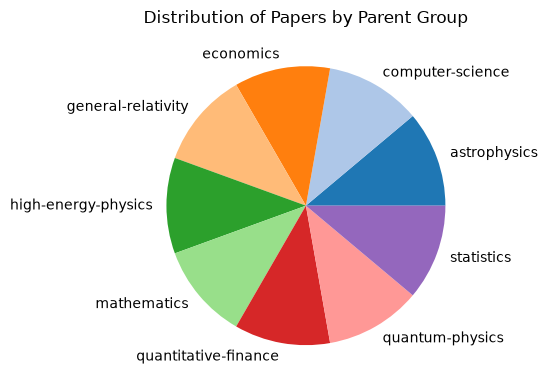

In [9]:
colors = plt.cm.tab20.colors
df["parent_group"].value_counts().plot(kind='pie', title='Distribution of Papers by Parent Group', figsize=(5, 4), colors=colors)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- **Data splitting into Training set, Validation set, Testing set**

In [10]:
# Split the data into training and testing sets
X_train, X_temp, y_train_str, y_temp_str, y_train_int, y_temp_int = train_test_split(
    df['text'],
    df['parent_group'], # Text targets
    df['label'],        # Integer targets
    train_size=0.70,    
    random_state=42,
    stratify=df['label']
)

X_val, X_test, y_val_str, y_test_str, y_val_int, y_test_int = train_test_split(
    X_temp, y_temp_str, y_temp_int,
    train_size=1800,  
    random_state=42,          
    stratify=y_temp_int
)
print("\n --- Splitting Boundary Verification ---")
print(f" Training Set:    X_train = {len(X_train)} samples")
print(f" Validation Set:  X_val = {len(X_val)} samples")
print(f" Testing Set:     X_test = {len(X_test)} samples")  #~11000 is a progressively larger set for testing the model's performance on unseen data
print(f" Confirm Training Class Balance:\n {y_train_str.value_counts()}")


 --- Splitting Boundary Verification ---
 Training Set:    X_train = 12600 samples
 Validation Set:  X_val = 1800 samples
 Testing Set:     X_test = 3600 samples
 Confirm Training Class Balance:
 parent_group
general-relativity      1400
mathematics             1400
quantum-physics         1400
economics               1400
astrophysics            1400
computer-science        1400
high-energy-physics     1400
statistics              1400
quantitative-finance    1400
Name: count, dtype: int64


- **Text Pre-processing**

Creating a function 'text_prep' for text cleaning and pre-processing, which will also be used for further uses.

In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1]

    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def text_prep(text):                    
    if text is None:
        return ""

    text = text.lower()  # Lowercase
    text =re.sub(r'\s+', ' ', text)  # Remove extra whitespace
    text =re.sub(r'\$.*?\$', ' ', text)  # Remove LaTeX math expressions
    text =re.sub(r'\\[a-zA-Z]+', ' ', text)  # Remove LaTeX commands
    text =re.sub(r'[^a-zA-Z\s]', ' ', text)  # Remove punctuation and numbers
    words = text.split()
    cleaned_tokens = [word for word in words if len(word) > 2]
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in cleaned_tokens
    ]

    return ' '.join(lemmatized_tokens)
#Apply text preprocessing to the training, validation, and test sets
print("--> Preprocessing text data for training data")
X_train_cleaned = X_train.apply(text_prep)
print(" Done!")
print(" -->Preprocessing text data for validation data")
X_val_cleaned = X_val.apply(text_prep)
print(" Done!")
print("-->Preprocessing text data for test data")
X_test_cleaned = X_test.apply(text_prep)
print(" Done!")
print("Text pre-processing completed successfully without data leakage!")
print("Checking The Preprocessed Data... :")
print(f" Raw Input String (Truncated):\n{X_train.iloc[8][:180]}...")
print(f"\n Cleaned Output String (Truncated):\n{X_train_cleaned.iloc[8][:180]}...")

--> Preprocessing text data for training data
 Done!
 -->Preprocessing text data for validation data
 Done!
-->Preprocessing text data for test data
 Done!
Text pre-processing completed successfully without data leakage!
Checking The Preprocessed Data... :
 Raw Input String (Truncated):
Nonclassical correlation properties of radiation fields.   A full characterization of nonclassical space-time dependent correlations of radiation is formulated in terms of normally...

 Cleaned Output String (Truncated):
nonclassical correlation property radiation field full characterization nonclassical space time dependent correlation radiation formulate term normally and time order field correla...


- **Exploratory Data Analysis EDA**


 > Temporary EDA DataFrame created successfully for exploratory analysis.

Top 5 Words in [ASTROPHYSICS]:


,Word,Frequency
0,star,1712
1,galaxy,1494
2,mass,1268
3,ray,1152
4,cluster,919



Top 5 Words in [COMPUTER-SCIENCE]:


,Word,Frequency
0,use,1097
1,algorithm,931
2,problem,854
3,base,786
4,network,773



Top 5 Words in [ECONOMICS]:


...


Top 5 Words in [QUANTUM-PHYSICS]:


,Word,Frequency
0,quantum,2827
1,state,1985
2,entanglement,815
3,use,678
4,field,574



Top 5 Words in [STATISTICS]:


,Word,Frequency
0,use,1342
1,algorithm,799
2,distribution,757
3,base,713
4,sample,679



 > Rendering WordCloud visual grids...


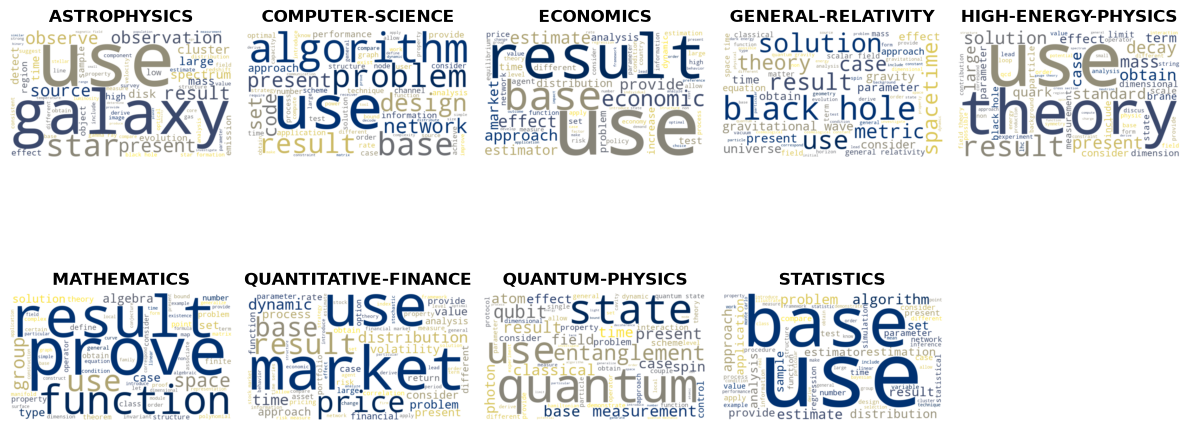

# EDA Visualizations Generated Successfully!


In [12]:
#Creating a temporary dataframe having preprocessed text and corresponding labels .
eda_df = pd.DataFrame({'text': X_train_cleaned, 'parent_group': y_train_str})
print("\n > Temporary EDA DataFrame created successfully for exploratory analysis.")
academic_stops = set(ENGLISH_STOP_WORDS).union({
    'paper', 'propose', 'method', 'results', 'study', 'based', 'using', 'new', 'model', 'data'
})

for category_name in sorted(eda_df['parent_group'].unique()):
    # Collect all text belonging to this specific class
    class_text = " ".join(eda_df[eda_df['parent_group'] == category_name]['text'])

    # Quick, simple string splitting for the text table
    words = class_text.lower().split()
    cleaned_words = [w.strip('.,()[]{}:;"\'?') for w in words if w.isalpha() and w not in academic_stops and len(w) > 2]

    word_counts = Counter(cleaned_words)
    top_words = word_counts.most_common(5)
    top_words_df = pd.DataFrame(top_words,columns=["Word", "Frequency"])
    print(f"\nTop 5 Words in [{category_name.upper()}]:")
    display(top_words_df)

print("\n > Rendering WordCloud visual grids...")

# Set up a 2x4 grid to cleanly accommodate all 9 classes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for idx, category_name in enumerate(sorted(eda_df['parent_group'].unique())):
    class_text = " ".join(eda_df[eda_df['parent_group'] == category_name]['text'])

    # Initialize and fit the WordCloud matrix
    wordcloud = WordCloud(width=700,height=400,background_color='white',max_words=70,stopwords=academic_stops,colormap='cividis',random_state=42).generate(class_text)

    # Plot configuration settings
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"{category_name.upper()}", fontsize=12, fontweight='bold')
    axes[idx].axis('off')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()
print("# EDA Visualizations Generated Successfully!")

In [13]:
df['word_count'] = df['text'].str.split().str.len()

words_per_class = df.groupby('parent_group')['word_count'].sum().sort_values(ascending=False)  #word counts for calculating tf idf in the manual way.

words_per_class

parent_group
astrophysics            379886
economics               311160
statistics              293081
computer-science        278705
quantitative-finance    278628
general-relativity      248638
high-energy-physics     235486
quantum-physics         228305
mathematics             189906
Name: word_count, dtype: int64

In [14]:
word = "algebra"  #Useful while calculating the document frequency of a word in the entire corpus,in a manual way. It is used to calculate the IDF score of a word in the corpus.

doc_f = df['text'].str.lower().apply(
    lambda x: word in x.split()
).sum()

print(doc_f)

264


- **TFIDF Feature Extraction**

##### Term-Frequency Inverse Document Frequency 
 * n_grams =(1,3) has Unigrams,Bigrams,Trigrams.
 * Captures more context.
 * norm =l2 prevents bias towards longer documents.
 * sub_linear=True frquency scaling instead of raw term frequency 

In [15]:
print(" Extracting vocabulary weights via TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=25000,       # Captures the core 9-class structural language
    stop_words='english',
    sublinear_tf =True,
    ngram_range=(1, 3),      # Picks up word couples like "machine learning"
    min_df=3 ,
    max_df=0.8,
    norm='l2'                # Cuts out rare noise and misspellings
)

# Fit and transform exclusively on the training pool
X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)

# Transform the verification partitions cleanly
X_val_tfidf = vectorizer.transform(X_val_cleaned)
X_test_tfidf = vectorizer.transform(X_test_cleaned)

print(f" TF-IDF vectors generated. Matrix feature shape: {X_train_tfidf.shape}")


 Extracting vocabulary weights via TF-IDF...
 TF-IDF vectors generated. Matrix feature shape: (12600, 25000)


- **Training & Evaluating Machine Learning models: KNN,SVM,Randomforest**

    Training Support Vector Machine (LinearSVC)...
    Support Vector Machine (LinearSVC) Validation Score: 0.8822


Classification Report:
                      precision    recall  f1-score   support

        astrophysics       0.96      0.94      0.95       200
    computer-science       0.87      0.84      0.86       200
           economics       0.86      0.83      0.84       200
  general-relativity       0.85      0.90      0.87       200
 high-energy-physics       0.92      0.86      0.89       200
         mathematics       0.88      0.89      0.88       200
quantitative-finance       0.85      0.87      0.86       200
     quantum-physics       0.93      0.92      0.93       200
          statistics       0.83      0.89      0.86       200

            accuracy                           0.88      1800
           macro avg       0.88      0.88      0.88      1800
        weighted avg       0.88      0.88      0.88      1800

    Training K-Nearest Neighbors (KNN)...
    K-Nea

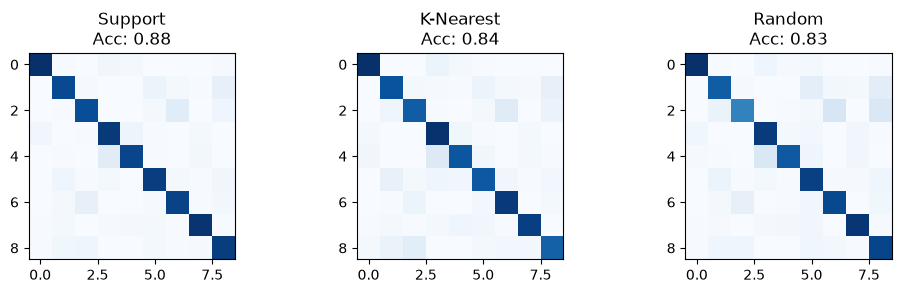

 * Classic Machine Learning execution pipeline completed!


In [16]:
models = {"Support Vector Machine (LinearSVC)": LinearSVC(random_state=42, C=1.0, max_iter=25000),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5, n_jobs=1),
    "Random Forest Classifier (RF)": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)}

# Variable memory array to pass scores downstream to our leaderboard cell later
classic_val_accuracies = {}

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
# Training loop using string targets
for idx, (name, model) in enumerate(list(models.items())[:3]):
    print(f"    Training {name}...")

    # Train using the text target arrays (y_train_str)
    model.fit(X_train_tfidf, y_train_str)

    # Evaluate validation accuracy
    val_preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val_str, val_preds)
    classic_val_accuracies[name] = acc

    print(f"    {name} Validation Score: {acc:.4f}\n")

        # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_val_str, val_preds))
    # Confusion Matrix
    cm = confusion_matrix(y_val_str, val_preds)
    axes[idx].imshow(cm, cmap="Blues")
    axes[idx].set_title(f"{name.split()[0]}\nAcc: {classic_val_accuracies[name]:.2f}")
plt.tight_layout()
plt.show()

print(" * Classic Machine Learning execution pipeline completed!")

- **Running cross-validation on training set to confirm generalized accuracies**

In [17]:
# 1. Initialize top manual model setup
model = {
    "Linear SVM": LinearSVC(C=1.0, loss='hinge', random_state=42, max_iter=25000),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}
print("Running 5-Fold Cross-Validation on Full Training Set...\n")
# 2. Run cross-validation 
for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train_str, cv=5, scoring="accuracy", n_jobs=-1)
    print(f"{name}:")
    print(f"Fold scores : {[f'{s:.4f}' for s in scores]}")
    print(f"Mean ± Std  : {scores.mean():.4f} ± {scores.std():.4f}")


Running 5-Fold Cross-Validation on Full Training Set...

Support Vector Machine (LinearSVC):
Fold scores : ['0.8790', '0.8829', '0.8798', '0.8873', '0.8782']
Mean ± Std  : 0.8814 ± 0.0034
K-Nearest Neighbors (KNN):
Fold scores : ['0.8413', '0.8520', '0.8413', '0.8524', '0.8413']
Mean ± Std  : 0.8456 ± 0.0053
Random Forest Classifier (RF):
Fold scores : ['0.8206', '0.8278', '0.8206', '0.8329', '0.8139']
Mean ± Std  : 0.8232 ± 0.0066


- **Comparing validation accuracies of models to test with the best model**

In [18]:
comparison_df = pd.DataFrame(
    list(classic_val_accuracies.items()),
    columns=["Model", "Validation Accuracy"])

comparison_df["Validation Accuracy"] = comparison_df["Validation Accuracy"].round(4)

comparison_df = comparison_df.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Validation Accuracy
0,Support Vector Machine (LinearSVC),0.8822
1,K-Nearest Neighbors (KNN),0.8367
2,Random Forest Classifier (RF),0.8261


##### **Therefore,among the above three models, Linear SVC performs comparatively well.**

- **Test with the best model i.e., Linear SVC on the "Unseen test data"**

Linear SVC Test Accuracy: 0.8867

Classification Report:
                      precision    recall  f1-score   support

        astrophysics       0.95      0.91      0.93       400
    computer-science       0.86      0.85      0.86       400
           economics       0.84      0.84      0.84       400
  general-relativity       0.87      0.90      0.89       400
 high-energy-physics       0.91      0.88      0.89       400
         mathematics       0.89      0.91      0.90       400
quantitative-finance       0.90      0.85      0.87       400
     quantum-physics       0.95      0.94      0.94       400
          statistics       0.82      0.89      0.85       400

            accuracy                           0.89      3600
           macro avg       0.89      0.89      0.89      3600
        weighted avg       0.89      0.89      0.89      3600



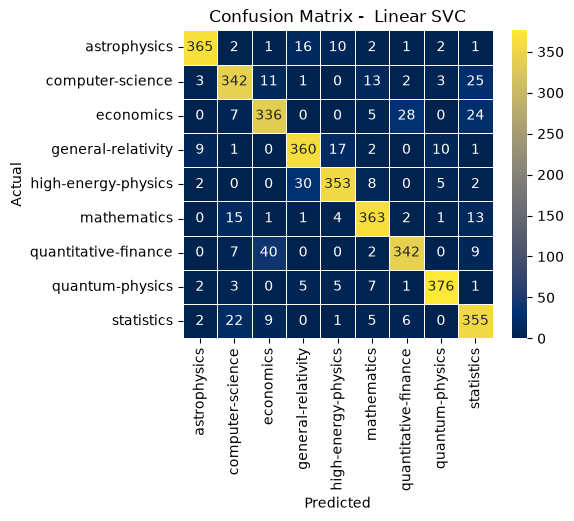

In [19]:
svm = LinearSVC(random_state=42, C=1.0, max_iter=25000)
svm.fit(X_train_tfidf, y_train_str)

# Predict on the test set
test_preds = svm.predict(X_test_tfidf)

# Test Accuracy
test_acc = accuracy_score(y_test_str, test_preds)
print(f"Linear SVC Test Accuracy: {test_acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_str, test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test_str, test_preds)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="cividis",linecolor="white",linewidths=0.5,
    xticklabels=["astrophysics","computer-science","economics","general-relativity","high-energy-physics",
                 "mathematics","quantitative-finance","quantum-physics","statistics"],
    yticklabels=["astrophysics","computer-science","economics","general-relativity",
                 "high-energy-physics","mathematics","quantitative-finance","quantum-physics","statistics"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -  Linear SVC")
plt.show()

- **Complete Overview of Linear SVM's Performance across the dataset**

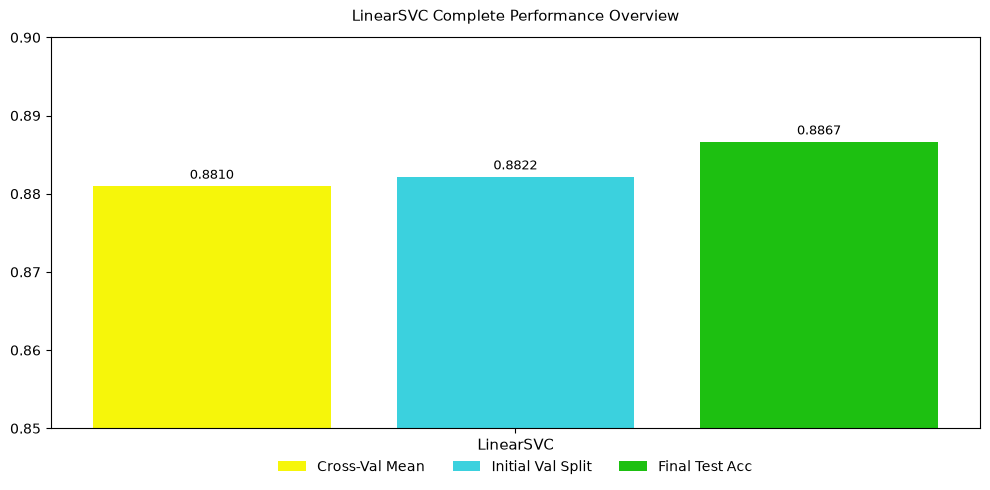

In [20]:
test_acc = accuracy_score(y_test_str, test_preds)
x = np.arange(1)
w = 0.18        # Thickness of bars
space = 0.23    # Distance between center points (must be larger than w)

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bars with clear breathing room between them
b1 = ax.bar(x - space, [0.8810], w, label='Cross-Val Mean', color="#f6f60a")
b2 = ax.bar(x,         [0.8822], w, label='Initial Val Split', color="#3bd1de")
b3 = ax.bar(x + space, [test_acc], w, label='Final Test Acc', color="#1dc011")

#Text formatting and layout cleanup
ax.set_title("LinearSVC Complete Performance Overview", fontsize=11, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(['LinearSVC'], fontsize=11)
ax.set_ylim(0.85,0.9)
ax.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15), frameon=False)

for b in [b1, b2, b3]: ax.bar_label(b, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


- **Topic Modelling with LatentDirichletAllocation LDA**

LDA is a powerful tool for topic modeling, enabling the discovery of hidden themes, designed to discover latent topics in large collection of text documents .

**LDA's Goal**- To identify these topics and determine the distribution of topics within each document and the distribution of words within each topic as it assumes each document is a mixture of topics and that each topic is a mixture of words.

In [22]:
lda_vectorizer = CountVectorizer(
    max_features=10000,
    stop_words='english',
    min_df=3,
    max_df=0.8
)

X_train_counts = lda_vectorizer.fit_transform(X_train_cleaned)

lda_model = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    n_jobs=-1
)

X_train_lda = lda_model.fit_transform(X_train_counts)

print("LDA model trained successfully.")
print("Document-topic matrix shape:", X_train_lda.shape)

LDA model trained successfully.
Document-topic matrix shape: (12600, 10)


In [23]:
# 1. Calculate the overall percentage weight of each topic across the entire dataset
topic_weights = X_train_lda.mean(axis=0) * 100

# 2. Extract feature names from LDA Count Vectorizer
feature_names = lda_vectorizer.get_feature_names_out()

print(" Unsupervised LDA Topics Breakdown (Topic Distribution % & Top Keywords):\n")

for topic_idx, topic in enumerate(lda_model.components_):
    # Sort top 10 word indices by statistical weight in descending order
    top_word_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_word_indices]
    
    # Topic dataset-wide percentage share
    share_pct = topic_weights[topic_idx]

    print(f" - LDA Topic #{topic_idx + 1} — Overall Weight: {share_pct:.2f}% of Dataset")
    print(f"  Keywords: {', '.join(top_words)}\n")

 Unsupervised LDA Topics Breakdown (Topic Distribution % & Top Keywords):

 - LDA Topic #1 — Overall Weight: 13.54% of Dataset
  Keywords: space, group, theory, solution, algebra, dimensional, graph, result, class, metric

 - LDA Topic #2 — Overall Weight: 12.82% of Dataset
  Keywords: market, model, price, network, risk, time, use, financial, stock, agent

 - LDA Topic #3 — Overall Weight: 3.36% of Dataset
  Keywords: cluster, state, galaxy, equilibrium, star, game, entanglement, formation, local, halo

 - LDA Topic #4 — Overall Weight: 7.56% of Dataset
  Keywords: model, distribution, test, time, process, volatility, use, data, stochastic, result

 - LDA Topic #5 — Overall Weight: 7.28% of Dataset
  Keywords: ray, star, emission, source, spectrum, high, galaxy, line, observation, model

 - LDA Topic #6 — Overall Weight: 15.92% of Dataset
  Keywords: model, field, energy, theory, equation, gravity, particle, quantum, mass, solution

 - LDA Topic #7 — Overall Weight: 10.74% of Dataset


- **Coherence score** - Computes the score to evaluate the quality of topics, in simpler words it measures how interpretable the topics are to humans. 

In [24]:
documents = X_train_cleaned
# Tokenize each document
# Each document becomes a list of words
texts = [
    document.split()
    for document in documents
]

# Create a Gensim dictionary
dictionary = Dictionary(texts)
# Get the top 10 words from each LDA topic
topics = []

feature_names = lda_vectorizer.get_feature_names_out()

for topic in lda_model.components_:

    top_word_indices = topic.argsort()[:-11:-1]

    top_words = [feature_names[i]
        for i in top_word_indices]

    topics.append(top_words)

# Calculate coherence score
coherence_model = CoherenceModel(
    topics=topics,
    texts=texts,
    dictionary=dictionary, 
    coherence='c_v',
    processes=1 
)
# Get overall coherence score
coherence_score = coherence_model.get_coherence()


print("LDA Coherence Score:", round(coherence_score, 4))

LDA Coherence Score: 0.5094


#### >Coherent scores range from 0 to 1. Here, with score of 0.5094 suggests that topics are reasonably coherent and interpretable.

- **LDA visualization**

In [26]:
pyLDAvis.enable_notebook()

lda_vis = pyLDAvis.lda_model.prepare(
    lda_model,
    X_train_counts,
    lda_vectorizer
)

pyLDAvis.display(lda_vis)

- **Sample papers to check results**

In [27]:
def predict_topic(text):
    # Same preprocessing used during training
    prep = text_prep(text)

    # TF-IDF features
    tfidf_features = vectorizer.transform([prep])
    # Predict
    pred = svm.predict(tfidf_features)[0]
    return pred


sample_papers = ["Newton's law of universal gravitation, which describes gravity in classical mechanics." ,
    "The map λ defined above is a bijection from the regions of Sn to the set of all parking functions of length n.",
    "Time-series data tracking changes in a star's brightness over days to find orbiting exoplanets.",
    "Evans and Pippenger showed in 1998 that noisy gates with 2 inputs are universal for arbitrary computation.",
    "Coincidence counts measuring spin correlations to prove quantum entanglement.",
    "The analysis of residuals plays an important role in validating the regression model.",
    "Quarterly inflation-adjusted percentage changes used to track national money reserves output.",
    "Digitized voltage pulses measuring particle shower energy deposits inside a detector grid in the Higgs case theory.",
    "Daily log-return percentages used to calculate portfolio risk and Value-at-Risk (VaR) models."]

for i, paper in enumerate(sample_papers, start=1):
    prediction = predict_topic(paper)

    print(f"Sample Paper {i}")
    print(f"Input Text         : {paper}")
    print(f"=>Predicted Category : {prediction}")
    print("-" * 90)
    print()

Sample Paper 1
Input Text         : Newton's law of universal gravitation, which describes gravity in classical mechanics.
=>Predicted Category : general-relativity
------------------------------------------------------------------------------------------

Sample Paper 2
Input Text         : The map λ defined above is a bijection from the regions of Sn to the set of all parking functions of length n.
=>Predicted Category : mathematics
------------------------------------------------------------------------------------------

Sample Paper 3
Input Text         : Time-series data tracking changes in a star's brightness over days to find orbiting exoplanets.
=>Predicted Category : astrophysics
------------------------------------------------------------------------------------------

Sample Paper 4
Input Text         : Evans and Pippenger showed in 1998 that noisy gates with 2 inputs are universal for arbitrary computation.
=>Predicted Category : computer-science
--------------------------

- **Saving best model, TFIDF Vectorizer, LDA model for further uses**

In [28]:
# Save the trained LinearSVC model
joblib.dump(svm, "best_svm_model.pkl")
# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
# Save the LDA vectorizer
joblib.dump(lda_vectorizer, "lda_vectorizer.pkl")
# Save the LDA model
joblib.dump(lda_model, "lda_model.pkl")
#Saving the LDA visualization as an HTML file for interactive exploration
pyLDAvis.save_html(lda_vis, "lda_visualization.html")
print(" ** All models saved successfully!")

 ** All models saved successfully!


- **Saving datasets to .csv**

In [29]:
#Saving the datasets to.csv files for future use
df.to_csv("arxiv_subset.csv", index=False)
print(" **Parsed dataset of 18k papers saved to 'arxiv_subset.csv' .")
X_train_cleaned.to_csv("X_train_cleaned.csv", index=False)
print("++Preprocessed training data of 12,600 papers saved to 'X_train_cleaned.csv'. ")
X_val_cleaned.to_csv("X_val_cleaned.csv", index=False)
print("++Preprocessed validation data of 1,800 papers saved to 'X_val_cleaned.csv'. ")
X_test_cleaned.to_csv("X_test_cleaned.csv", index=False)
print("++Preprocessed test data of 3,600 papers saved to 'X_test_cleaned.csv'. ")   

 **Parsed dataset of 18k papers saved to 'arxiv_subset.csv' .
++Preprocessed training data of 12,600 papers saved to 'X_train_cleaned.csv'. 
++Preprocessed validation data of 1,800 papers saved to 'X_val_cleaned.csv'. 
++Preprocessed test data of 3,600 papers saved to 'X_test_cleaned.csv'. 
